#### DRW - Crypto Market Prediction

Develop a model capable of predicting crypto future price movements.

Link to the competition: https://www.kaggle.com/competitions/drw-crypto-market-prediction/overview

The evaluation metric is: Pearson correlation coefficient (PCC)

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from autogluon.tabular import TabularPredictor

import plotly.express as px

In [2]:
data_path = "/home/yang/team_kaggle/drw/data"

In [3]:
data = pd.read_parquet(Path(data_path, "train.parquet"))
training_split = int(len(data) * 0.9)
training_data = data[:training_split].copy(deep=True)#.sample(frac=1.0, random_state=42)
training_data.head(10)

,bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,...,X772,X773,X774,X775,X776,X777,X778,X779,X780,label
2023-03-01 00:00:00,15.283,8.425,176.405,44.984,221.389,0.181844,-0.637860,0.006652,0.136870,0.116698,...,0.333753,-0.009992,-0.695595,-0.444077,-0.191238,-0.184251,-0.471897,-0.625428,-0.553991,0.562539
2023-03-01 00:01:00,38.590,2.336,525.846,321.950,847.796,0.489497,-0.075619,0.431594,0.522400,0.475255,...,0.333657,-0.010040,-0.696226,-0.452866,-0.200082,-0.188929,-0.472842,-0.625832,-0.554426,0.533686
2023-03-01 00:02:00,0.442,60.250,159.227,136.369,295.596,0.260121,-0.444684,0.100695,0.224729,0.203282,...,0.333667,-0.010037,-0.696832,-0.461383,-0.208786,-0.193571,-0.473785,-0.626236,-0.554860,0.546505
2023-03-01 00:03:00,4.865,21.016,335.742,124.963,460.705,0.099976,-0.666728,-0.123858,0.019197,0.014459,...,0.333174,-0.010279,-0.697391,-0.469628,-0.217350,-0.198175,-0.474726,-0.626639,-0.555294,0.357703
2023-03-01 00:04:00,27.158,3.451,98.411,44.407,142.818,0.270893,-0.325973,0.116336,0.234311,0.214073,...,0.333171,-0.010283,-0.697940,-0.477622,-0.225780,-0.202745,-0.475666,-0.627043,-0.555728,0.362452
2023-03-01 00:05:00,29.454,5.540,309.371,97.460,406.831,-0.558479,-1.655676,-1.033540,-0.814882,-0.756889,...,0.332504,-0.010610,-0.698384,-0.485338,-0.234063,-0.207272,-0.476601,-0.627445,-0.556162,0.100448
2023-03-01 00:06:00,3.478,29.514,100.608,233.525,334.133,-0.452937,-1.332166,-0.854345,-0.668494,-0.627297,...,0.332695,-0.010519,-0.698833,-0.492821,-0.242217,-0.211766,-0.477535,-0.627847,-0.556595,0.178679
2023-03-01 00:07:00,16.591,3.230,46.034,218.806,264.840,0.464475,0.292593,0.441009,0.498789,0.449966,...,0.333397,-0.010178,-0.699211,-0.500053,-0.250233,-0.216220,-0.478466,-0.628248,-0.557028,0.463684
2023-03-01 00:08:00,5.560,30.919,40.259,82.518,122.777,1.000941,1.145275,1.168142,1.166786,1.073158,...,0.333931,-0.009919,-0.699591,-0.507064,-0.258124,-0.220640,-0.479395,-0.628649,-0.557461,0.686066
2023-03-01 00:09:00,12.697,14.827,125.650,90.750,216.400,1.093672,1.193154,1.258610,1.264540,1.172654,...,0.333782,-0.009994,-0.699884,-0.513830,-0.265876,-0.225019,-0.480320,-0.629049,-0.557893,0.637539


In [4]:
validation_data = data[training_split:].copy(deep=True) # don't shuffle validation data
validation_data.head(10)

,bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,...,X772,X773,X774,X775,X776,X777,X778,X779,X780,label
2024-01-24 09:02:00,0.070,12.853,45.456,36.360,81.816,-0.116756,0.141446,0.074987,0.163434,0.185299,...,0.023867,-0.013762,-0.703436,-0.717370,-0.731388,-0.744534,-0.737445,-0.779743,-0.750662,0.779121
2024-01-24 09:03:00,3.139,1.316,20.868,14.201,35.069,0.046766,0.396610,0.298546,0.366863,0.374859,...,0.023643,-0.013951,-0.703443,-0.717375,-0.731393,-0.744589,-0.737657,-0.779935,-0.750961,0.648092
2024-01-24 09:04:00,8.418,4.192,45.910,15.620,61.530,-0.523014,-0.573309,-0.498472,-0.357309,-0.294076,...,0.023313,-0.014229,-0.703445,-0.717378,-0.731397,-0.744644,-0.737869,-0.780126,-0.751259,0.446330
2024-01-24 09:05:00,0.177,3.037,69.299,38.182,107.481,-0.985337,-1.278931,-1.121283,-0.934169,-0.831910,...,0.023231,-0.014299,-0.703433,-0.717376,-0.731399,-0.744697,-0.738079,-0.780317,-0.751558,0.401061
2024-01-24 09:06:00,1.667,5.310,31.562,33.043,64.605,-0.649794,-0.612698,-0.621414,-0.495928,-0.432921,...,0.023278,-0.014261,-0.703431,-0.717377,-0.731402,-0.744750,-0.738289,-0.780507,-0.751856,0.438660
2024-01-24 09:07:00,1.172,10.788,37.086,23.288,60.374,-1.286383,-1.600363,-1.481081,-1.290164,-1.173253,...,0.023128,-0.014389,-0.703429,-0.717379,-0.731405,-0.744803,-0.738499,-0.780697,-0.752154,0.349388
2024-01-24 09:08:00,1.268,4.381,38.668,42.454,81.122,-1.148550,-1.228958,-1.242826,-1.095285,-1.002485,...,0.023144,-0.014377,-0.703422,-0.717378,-0.731408,-0.744854,-0.738708,-0.780887,-0.752451,0.365554
2024-01-24 09:09:00,0.975,4.837,190.920,338.553,529.473,-1.349833,-1.447129,-1.480889,-1.331027,-1.229416,...,0.023243,-0.014297,-0.703376,-0.717363,-0.731402,-0.744902,-0.738915,-0.781076,-0.752748,0.435450
2024-01-24 09:10:00,1.517,8.725,87.418,334.715,422.133,-0.764657,-0.356455,-0.624446,-0.571639,-0.535423,...,0.023294,-0.014257,-0.703363,-0.717359,-0.731403,-0.744952,-0.739122,-0.781265,-0.753045,0.475690
2024-01-24 09:11:00,11.163,0.069,31.072,30.803,61.875,-1.086987,-0.852341,-1.049733,-0.968535,-0.907667,...,0.023187,-0.014349,-0.703371,-0.717362,-0.731407,-0.745004,-0.739330,-0.781454,-0.753343,0.414450


In [5]:
del data

In [6]:
# create new features to capture market microstructure dynamics
def new_features(df):
    feature_pool = ["bid_ask_interaction", "bid_buy_interaction", "bid_sell_interaction", "ask_buy_interaction", "ask_sell_interaction", "buy_sell_interaction"]
    # Create interaction features for df
    df['bid_ask_interaction'] = df['bid_qty'] * df['ask_qty']
    df['bid_buy_interaction'] = df['bid_qty'] * df['buy_qty']
    df['bid_sell_interaction'] = df['bid_qty'] * df['sell_qty']
    df['ask_buy_interaction'] = df['ask_qty'] * df['buy_qty']
    df['ask_sell_interaction'] = df['ask_qty'] * df['sell_qty']
    df['buy_sell_interaction'] = df['buy_qty'] * df['sell_qty']
    # Add more features if needed
    # df['volume_weighted_sell'] = df['sell_qty'] * df['volume']
    # df['buy_sell_ratio'] = df['buy_qty'] / (df['sell_qty'] + 1e-8)
    # df['selling_pressure'] = df['sell_qty'] / (df['volume'] + 1e-8)
    # df['effective_spread_proxy'] = np.abs(df['buy_qty'] - df['sell_qty']) / (df['volume'] + 1e-8)
    return df, feature_pool

In [7]:
training_data_with_inter_features, feature_pool = new_features(training_data)
validation_data_with_inter_features, _ = new_features(validation_data)

In [8]:
#train_feature_list = training_data.columns[:-2]  # Exclude 'label' and 'timestamp'

# train_feature_list = [
#     "X344", "X598", "X862", "X385", "X852", "X603", "X860", "X674",
#     "X415", "X345", "X137", "X855", "X174", "X302", "X178", "X532", "X168", "X612",
#     "bid_qty", "ask_qty", "buy_qty", "sell_qty", "volume"
# ]

train_feature_list = ["X40", "X137", "X168", "X169", "X173", "X174", "X178", "X179", "X197", "X198",
                      "X302", "X333", "X345", "X385", "X415", "X421", "X598", "X603", "X612", "X674",
                       "buy_qty", "sell_qty", "volume"]


In [9]:
selected_data = training_data[train_feature_list+ ["label"] + feature_pool]
selected_data.head()

,X40,X137,X168,X169,X173,X174,X178,X179,X197,X198,...,buy_qty,sell_qty,volume,label,bid_ask_interaction,bid_buy_interaction,bid_sell_interaction,ask_buy_interaction,ask_sell_interaction,buy_sell_interaction
2023-03-01 00:00:00,0.413994,0.671167,-0.734976,-1.357882,1.332374,-0.691527,-0.102525,1.051957,-1.206252,-1.075458,...,176.405,44.984,221.389,0.562539,128.759275,2695.997615,687.490472,1486.212125,378.990200,7935.402520
2023-03-01 00:01:00,0.400787,0.670053,-0.733172,-1.366976,1.328275,-0.690872,-0.102463,1.050236,-1.156824,-1.041984,...,525.846,321.950,847.796,0.533686,90.146240,20292.397140,12424.050500,1228.376256,752.075200,169296.119700
2023-03-01 00:02:00,0.399768,0.668940,-0.731378,-1.366018,1.324187,-0.690220,-0.102400,1.048519,-1.145618,-1.034695,...,159.227,136.369,295.596,0.546505,26.630500,70.378334,60.275098,9593.426750,8216.232250,21713.626763
2023-03-01 00:03:00,0.455040,0.667829,-0.764601,-1.364450,1.320110,-0.709082,-0.102338,1.046803,-1.077707,-0.989103,...,335.742,124.963,460.705,0.357703,102.242840,1633.384830,607.944995,7055.953872,2626.222408,41955.327546
2023-03-01 00:04:00,0.444652,0.666719,-0.762633,-1.358550,1.316045,-0.708379,-0.102276,1.045090,-1.045787,-0.967911,...,98.411,44.407,142.818,0.362452,93.722258,2672.645938,1206.005306,339.616361,153.248557,4370.137277


In [10]:
# Hyperparameters for the TabularPredictor
time_limit = 30 * 60  # train various models for ~30 min
num_trials = 5  # try at most 5 different hyperparameter configurations for each type of model
search_strategy = 'auto'  # to tune hyperparameters using random search routine with a local scheduler


# hyperparameter_tune_kwargs = {  # HPO is not performed unless hyperparameter_tune_kwargs is specified
#     'num_trials': num_trials,
#     'scheduler' : 'local',
#     'searcher': search_strategy,
# }

In [11]:
# predictor = TabularPredictor(label="label").fit(
#     training_data[train_feature_list+ ["label"]][:training_split],
#     time_limit=time_limit,
#     num_bag_folds=5, num_bag_sets=1, num_stack_levels=1,
#     # hyperparameters=hyperparameters,
#     # hyperparameter_tune_kwargs=hyperparameter_tune_kwargs,
# )

predictor = TabularPredictor(label="label").fit(
    training_data_with_inter_features[train_feature_list+ ["label"] + feature_pool],
    time_limit=time_limit,
    auto_stack=True,
    num_bag_folds=5, num_bag_sets=1, num_stack_levels=1,
    #presets='best_quality',
    # hyperparameters=hyperparameters,
    # hyperparameter_tune_kwargs=hyperparameter_tune_kwargs,
)

No path specified. Models will be saved in: "AutogluonModels/ag-20250711_122328"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.3.1
Python Version:     3.12.10
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025
CPU Count:          16
Memory Avail:       17.72 GB / 27.41 GB (64.7%)
Disk Space Avail:   644.63 GB / 1006.85 GB (64.0%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='experimental' : New in v1.2: Pre-trained foundation model + parallel fits. The absolute best accuracy without consideration for inference speed. Does not support GPU.
	presets='best'         : Maximize accuracy. Recommended for most users. Use in competit

(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. RayTask ID: 316636158529ac18ed787dc0cffd6bb777432b9f01000000 Worker ID: 9a49e091911c04ef4538a7c6f4b9694862464af1281f8350a283fc30 Node ID: 7a9d8e7c1d0bd0120d1d6afccf550e81a9fee4d7b17b16b567cf5721 Worker IP address: 192.168.178.223 Worker port: 45933 Worker PID: 61631 Worker exit type: SYSTEM_ERROR Worker exit detail: Worker unexpectedly exits with a connection error code 2. End of file. There are some potential root causes. (1) The process is killed by SIGKILL by OOM killer due to high memory usage. (2) ray stop --force is called. (3) The worker is crashed unexpectedly due to SIGSEGV or other unexpected errors.
(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. RayTask ID: 8da10906dda62219732f3051dbe372b35d7b234401000000 Worker ID

		The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.
Detailed Traceback:
Traceback (most recent call last):
  File "/home/yang/team_kaggle/drw/DRW/.venv/lib/python3.12/site-packages/autogluon/tabular/trainer/abstract_trainer.py", line 2169, in _train_and_save
    model = self._train_single(**model_fit_kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/yang/team_kaggle/drw/DRW/.venv/lib/python3.12/site-packages/autogluon/tabular/trainer/abstract_trainer.py", line 2055, in _train_single
    model = model.fit(X=X, y=y, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test, total_resources=total_resources, **model_fit_kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/yang/team_kaggle/drw/DRW/.venv/lib/python3.12/site-packages/autogluon/core/models/abstract/abstract_model.py", line 1051, in fit

(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. RayTask ID: 8ac9f5fa3503be354d8c290b89e5d8cceda9dc4301000000 Worker ID: 38ee5c8428e8738071d16a1e549286809c386b1197a7ebc5d7f679f7 Node ID: 7a9d8e7c1d0bd0120d1d6afccf550e81a9fee4d7b17b16b567cf5721 Worker IP address: 192.168.178.223 Worker port: 46113 Worker PID: 62730 Worker exit type: SYSTEM_ERROR Worker exit detail: Worker unexpectedly exits with a connection error code 2. End of file. There are some potential root causes. (1) The process is killed by SIGKILL by OOM killer due to high memory usage. (2) ray stop --force is called. (3) The worker is crashed unexpectedly due to SIGSEGV or other unexpected errors.


Fitting model: WeightedEnsemble_L2 ... Training model for up to 360.00s of the 514.33s of remaining time.
	Ensemble Weights: {'RandomForestMSE_BAG_L1': 0.526, 'LightGBM_BAG_L1': 0.474}
	-0.1853	 = Validation score   (-root_mean_squared_error)
	0.52s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting 9 L2 models, fit_strategy="sequential" ...
Fitting model: LightGBMXT_BAG_L2 ... Training model for up to 513.74s of the 513.69s of remaining time.
	Fitting 5 child models (S1F1 - S1F5) | Fitting with ParallelLocalFoldFittingStrategy (5 workers, per: cpus=3, gpus=0, memory=5.29%)


...

2025-07-11 14:44:59,845	ERROR worker.py:422 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.
2025-07-11 14:45:04,850	ERROR worker.py:422 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.


(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. RayTask ID: c93d6c8c2d607327566b2e0fcc4ec9a042e3580301000000 Worker ID: e03b0d8daa87d0c4f22d4f5a9e27c04d57d15ffde50f61b7075469d6 Node ID: 7a9d8e7c1d0bd0120d1d6afccf550e81a9fee4d7b17b16b567cf5721 Worker IP address: 192.168.178.223 Worker port: 46529 Worker PID: 62899 Worker exit type: SYSTEM_ERROR Worker exit detail: Worker unexpectedly exits with a connection error code 2. End of file. There are some potential root causes. (1) The process is killed by SIGKILL by OOM killer due to high memory usage. (2) ray stop --force is called. (3) The worker is crashed unexpectedly due to SIGSEGV or other unexpected errors.


2025-07-11 14:45:13,858	ERROR worker.py:422 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.


(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. RayTask ID: 47df874fb0d9738b0b8a6bc1f053fbac8526d38601000000 Worker ID: 9a7283acc55041d1d6f2a31c25d137cc717a66d177c629e195667def Node ID: 7a9d8e7c1d0bd0120d1d6afccf550e81a9fee4d7b17b16b567cf5721 Worker IP address: 192.168.178.223 Worker port: 45795 Worker PID: 63046 Worker exit type: SYSTEM_ERROR Worker exit detail: Worker unexpectedly exits with a connection error code 2. End of file. There are some potential root causes. (1) The process is killed by SIGKILL by OOM killer due to high memory usage. (2) ray stop --force is called. (3) The worker is crashed unexpectedly due to SIGSEGV or other unexpected errors.


2025-07-11 14:45:23,870	ERROR worker.py:422 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.
	-0.1594	 = Validation score   (-root_mean_squared_error)
	267.38s	 = Training   runtime
	386.32s	 = Validation runtime
Fitting model: LightGBM_BAG_L2 ... Training model for up to 179.46s of the 179.41s of remaining time.
	Fitting 5 child models (S1F1 - S1F5) | Fitting with ParallelLocalFoldFittingStrategy (5 workers, per: cpus=3, gpus=0, memory=4.66%)
	-0.1553	 = Validation score   (-root_mean_squared_error)
	141.5s	 = Training   runtime
	204.08s	 = Validation runtime
Fitting model: WeightedEnsemble_L3 ... Training model for up to 360.00s of the -9.05s of remaining time.
	Ensemble Weights: {'LightGBM_BAG_L2': 0.72, 'LightGBMXT_BAG_L2': 0.24, 'ExtraTreesMSE_BAG_L1': 0.04}
	-0.1546	 = Validation score   (-root_mean_squared_error)
	0.48s	 = Training   runtime
	0.0s

In [ ]:
# predictor.evaluate(training_data[train_feature_list+ ["label"]][training_split:])
predictor.evaluate(validation_data_with_inter_features[train_feature_list+ ["label"] + feature_pool])

In [20]:
# Note that this will take a long time to run, as it computes feature importance for all features
# predictor.feature_importance(training_data[train_feature_list+ ["label"]][training_split:])
predictor.feature_importance(validation_data_with_inter_features[train_feature_list+ ["label"] + feature_pool])

Computing feature importance via permutation shuffling for 29 features using 5000 rows with 5 shuffle sets...
	2087.9s	= Expected runtime (417.58s per shuffle set)
	1695.24s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
X385,0.043090,0.011078,0.000481,5,0.065900,0.020280
X169,0.038348,0.004120,0.000016,5,0.046830,0.029865
X173,0.024760,0.002679,0.000016,5,0.030277,0.019244
X345,0.021985,0.004177,0.000149,5,0.030586,0.013385
X179,0.016910,0.004394,0.000501,5,0.025957,0.007864
X174,0.011103,0.000924,0.000006,5,0.013004,0.009201
X198,0.009765,0.003258,0.001290,5,0.016474,0.003056
X421,0.009667,0.001414,0.000053,5,0.012578,0.006755
X333,0.007949,0.003691,0.004276,5,0.015548,0.000349
X40,0.006939,0.006246,0.033948,5,0.019800,-0.005921


In [19]:
# predictor.leaderboard(training_data[train_feature_list+ ["label"]][training_split:])
predictor.leaderboard(validation_data_with_inter_features[train_feature_list+ ["label"] + feature_pool])

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,ExtraTreesMSE_BAG_L1,-1.114799,-0.215576,root_mean_squared_error,1.243702,2.548367,17.621520,1.243702,2.548367,17.621520,1,True,7
1,KNeighborsUnif_BAG_L1,-1.134433,-1.100400,root_mean_squared_error,12.085036,124.048925,0.960607,12.085036,124.048925,0.960607,1,True,1
2,KNeighborsDist_BAG_L1,-1.138833,-1.107372,root_mean_squared_error,12.768867,120.878202,0.810969,12.768867,120.878202,0.810969,1,True,2
3,WeightedEnsemble_L3,-1.139938,-0.154587,root_mean_squared_error,106.438401,1601.488670,1171.893286,0.004257,0.004570,0.483171,3,True,11
4,WeightedEnsemble_L2,-1.140030,-0.185311,root_mean_squared_error,22.759152,370.883315,376.678834,0.005149,0.007200,0.524090,2,True,8
5,LightGBM_BAG_L2,-1.142336,-0.155291,root_mean_squared_error,78.253603,1215.160779,904.027382,5.827148,204.075564,141.502827,2,True,10
6,LightGBMXT_BAG_L2,-1.143548,-0.159395,root_mean_squared_error,100.606996,1397.408536,1029.907288,28.180540,386.323321,267.382733,2,True,9
7,CatBoost_BAG_L1,-1.163017,-0.461531,root_mean_squared_error,0.308681,0.391382,171.206542,0.308681,0.391382,171.206542,1,True,6
8,LightGBM_BAG_L1,-1.164273,-0.204048,root_mean_squared_error,22.055824,369.166074,202.526108,22.055824,369.166074,202.526108,1,True,4
9,LightGBMXT_BAG_L1,-1.165982,-0.269562,root_mean_squared_error,23.266168,392.342225,195.770174,23.266168,392.342225,195.770174,1,True,3


#### Model evaluation

In [12]:
# load saved model to make predictions
#predictor = TabularPredictor.load('AutoGluonModels/ag-20250615_101641/models')
# y_pred = predictor.predict(training_data[train_feature_list][training_split:])
y_pred = predictor.predict(validation_data_with_inter_features[train_feature_list+feature_pool])

y_pred

2024-01-24 09:02:00    0.572751
2024-01-24 09:03:00    0.482844
2024-01-24 09:04:00    0.370051
2024-01-24 09:05:00    0.226688
2024-01-24 09:06:00    0.258565
                         ...   
2024-02-29 23:55:00    0.205303
2024-02-29 23:56:00    0.153958
2024-02-29 23:57:00    0.132380
2024-02-29 23:58:00    0.287172
2024-02-29 23:59:00    0.287718
Name: label, Length: 52589, dtype: float32

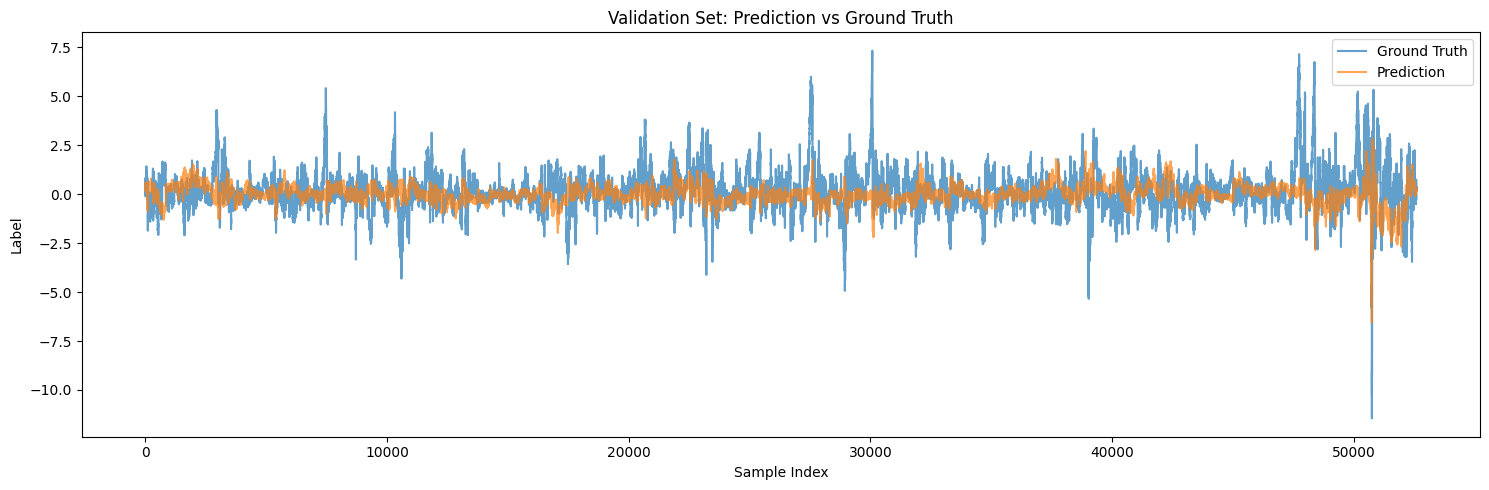

In [13]:
import matplotlib.pyplot as plt

# Get ground truth labels for the validation set
# y_true = training_data["label"][training_split:].to_numpy().flatten()

y_true = validation_data_with_inter_features["label"].to_numpy().flatten()

plt.figure(figsize=(15, 5))
plt.plot(y_true, label='Ground Truth', alpha=0.7)
plt.plot(y_pred.values, label='Prediction', alpha=0.7)
plt.title('Validation Set: Prediction vs Ground Truth')
plt.xlabel('Sample Index')
plt.ylabel('Label')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
from scipy.stats import pearsonr

# Calculate Pearson correlation coefficient
pcc, _ = pearsonr(y_true, y_pred.values)
print("Pearson correlation coefficient (PCC):", pcc)

Pearson correlation coefficient (PCC): 0.009305765784840013


#### Predictions with test data for submission

In [15]:
testing_data = pd.read_parquet(Path(data_path, "test.parquet"))
testing_data = testing_data.drop(columns=["label"])
testing_data.head(10)

,bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,...,X771,X772,X773,X774,X775,X776,X777,X778,X779,X780
ID,,,,,,,,,,,,,,,,,,,,,
1,0.317,8.102,13.164,10.272,23.436,-0.341229,0.041851,-0.020094,-0.206221,-0.297124,...,-0.525974,-0.147911,-0.043417,1.521787,1.548965,1.495735,1.166730,0.281056,-0.187831,-0.599553
2,2.608,2.111,123.562,40.163,163.725,-1.029564,-1.382505,-1.214935,-1.020241,-0.960397,...,-0.340076,-0.126703,-0.077090,-0.703054,-0.716951,-0.721292,-0.674619,-0.639318,-0.736268,-0.862220
3,2.768,10.787,126.137,118.266,244.403,-2.594090,-5.486158,-4.744466,-3.930152,-3.275324,...,2.131345,-0.147750,-0.030627,-0.703514,-0.717525,-0.731701,-0.750998,-0.789366,-0.850941,-1.033131
4,0.948,12.157,16.069,31.723,47.792,0.240745,0.997585,1.028965,1.081052,0.811895,...,0.524579,-0.136737,-0.033380,1.521167,1.551771,1.582833,1.625830,1.762155,1.911924,1.962445
5,1.084,3.493,32.679,37.327,70.006,0.067189,0.772852,0.772152,0.714846,0.514422,...,-0.523453,-0.218991,-0.004915,-0.703161,-0.716900,-0.714699,-0.652209,-0.623165,-0.699887,-0.640094
6,0.791,7.437,22.597,12.342,34.939,-0.202193,-0.431540,-0.525282,-0.586427,-0.630476,...,-0.353245,-0.198320,-0.085736,1.523340,1.553988,1.584628,1.595013,1.150255,0.588374,0.024996
7,2.296,1.195,176.867,78.398,255.265,1.090759,-0.909704,-0.204441,0.142584,0.358128,...,0.363553,-0.219176,-0.066952,-0.703419,-0.717470,-0.731672,-0.751103,-0.723096,-0.381238,0.235638
8,11.111,12.663,14.508,19.957,34.465,1.306755,0.818914,1.558436,1.734842,1.694095,...,0.271059,-0.227175,-0.022281,-0.703531,-0.717535,-0.731715,-0.751181,-0.798122,-0.864106,-1.048633
9,2.729,4.766,30.114,7.165,37.279,-0.006084,-0.364601,-0.197368,0.021197,0.117522,...,-0.042336,-0.235899,-0.052247,1.523294,1.553927,1.579491,1.513038,0.832172,0.263215,-0.253831


In [16]:
testing_data_with_inter_features, _ = new_features(testing_data)

In [17]:
# predict on the test set
#predictions = predictor.predict(testing_data[train_feature_list])
predictions = predictor.predict(testing_data_with_inter_features[train_feature_list + feature_pool])

# prepare submission DataFrame
submission_df = pd.DataFrame({
    "ID": np.arange(1, len(predictions)+1),
    "prediction": predictions
})
submission_df.to_csv("submission.csv", index=False)
submission_df

,ID,prediction
ID,,
1,1,-0.339502
2,2,0.051836
3,3,-0.855967
4,4,0.100427
5,5,-0.253267
...,...,...
538146,538146,0.820544
538147,538147,0.068336
538148,538148,-0.897944


In [18]:
sample_submission = pd.read_csv(Path(data_path, "sample_submission.csv"))
sample_submission.head(10)

,ID,prediction
0,1,-0.280233
1,2,1.371969
2,3,-2.045252
3,4,-1.447555
4,5,-1.303901
5,6,1.659284
6,7,1.376758
7,8,0.237542
8,9,-0.101127
9,10,1.267094
